# 🌾 KIỂM THỬ MÔ HÌNH YOLO-SEG + SAHI BÓC TÁCH HẠT LÚA THÀNH ẢNH PNG
**Mục đích**:
- Kiểm tra độc lập khả năng bóc tách phân đoạn (segmentation) của mô hình YOLOv8-seg mới nhất kết hợp với cơ chế trượt **SAHI** (Slicing Aided Hyper Inference).
- Cắt từng hạt lúa thành ảnh riêng biệt định dạng **PNG trong suốt (4 kênh RGBA)** và lưu vào thư mục.
- Trực quan hóa toàn bộ hạt trên ảnh gốc và lưới ảnh (gallery) từng hạt bóc tách được.
- Đóng gói file `.zip` để tải toàn bộ ảnh hạt về máy kiểm tra.


In [1]:
# Bước 1: Kết nối Google Drive & Cài đặt thư viện
from google.colab import drive
drive.mount('/content/drive')

!pip install ultralytics sahi opencv-python matplotlib numpy


Mounted at /content/drive
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.5/45.5 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 23.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 151.8/151.8 kB 14.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.2/53.2 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.9/63.9 kB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.9/115.9 kB 11.3 MB/s eta 0:00:00


In [2]:
# Bước 2: Import Thư viện & Cấu hình Đường dẫn
import os
import sys
import cv2
import math
import time
import shutil
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# 1. Đường dẫn thư mục dự án trên Google Drive
BASE_PATH = "/content/drive/MyDrive/NGHIÊN CỨU KHOA HỌC/GROUP_MEMBERS/NGUYEN MINH TRI/MAIN_SOURCES"

# 2. Trọng số mô hình YOLO vừa train
YOLO_MODEL_PATH = os.path.join(BASE_PATH, "/content/drive/MyDrive/NGHIÊN CỨU KHOA HỌC/GROUP_MEMBERS/NGUYEN MINH TRI/MAIN_SOURCES/RESULTS/35_special_images_segmentation.v1i.yolov8_v1_trained")

# 3. Ảnh mẫu để kiểm tra (Bạn có thể đổi sang ảnh khác bất kỳ)
TEST_IMAGE_PATH = os.path.join(BASE_PATH, "DATASET_BUILDER/1_Raw_Images/M001/M001A.jpg")

# 4. Thư mục xuất các file ảnh PNG từng hạt lúa
OUTPUT_PNG_DIR = "/content/test_sahi_crops"
os.makedirs(OUTPUT_PNG_DIR, exist_ok=True)

print("=" * 60)
print(f"🔹 Model YOLO      : {YOLO_MODEL_PATH}")
print(f"🔹 Ảnh Test mẫu    : {TEST_IMAGE_PATH}")
print(f"🔹 Thư mục lưu PNG : {OUTPUT_PNG_DIR}")
print("=" * 60)


🔹 Model YOLO      : /content/drive/MyDrive/NGHIÊN CỨU KHOA HỌC/GROUP_MEMBERS/NGUYEN MINH TRI/MAIN_SOURCES/RESULTS/all-new-data-v1.yolov8_yolov8s-seg_trained/weights/best.pt
🔹 Ảnh Test mẫu    : /content/drive/MyDrive/NGHIÊN CỨU KHOA HỌC/GROUP_MEMBERS/NGUYEN MINH TRI/MAIN_SOURCES/DATASET_BUILDER/1_Raw_Images/M001/M001A.jpg
🔹 Thư mục lưu PNG : /content/test_sahi_crops


In [3]:
# Bước 3: Nạp Mô hình YOLO-seg qua SAHI
from sahi import AutoDetectionModel
from sahi.predict import get_sliced_prediction

print("⏳ Đang khởi tạo SAHI AutoDetectionModel với GPU...")
detection_model = AutoDetectionModel.from_pretrained(
    model_type="yolov8",
    model_path=YOLO_MODEL_PATH,
    confidence_threshold=0.40,  # Ngưỡng tin cậy
    device="cuda:0"            # Sử dụng GPU
)
print("✅ Nạp Model thành công!")


⏳ Đang khởi tạo SAHI AutoDetectionModel với GPU...
Creating new Ultralytics Settings v0.0.7 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
✅ Nạp Model thành công!


In [4]:
# Bước 4: Chạy SAHI Sliced Prediction & Bóc Tách Hạt Thành Ảnh PNG Trong Suốt
# Đọc ảnh gốc
img_bgr = cv2.imread(TEST_IMAGE_PATH)
if img_bgr is None:
    raise FileNotFoundError(f"❌ Không tìm thấy ảnh tại: {TEST_IMAGE_PATH}")

h_orig, w_orig = img_bgr.shape[:2]
print(f"📸 Kích thước ảnh gốc: {w_orig}x{h_orig} pixels")

# CẤU HÌNH SIÊU THAM SỐ SAHI
SLICE_SIZE    = 640    # Kích thước ô trượt (512x512)
OVERLAP_RATIO = 0.25   # Tỷ lệ gối đầu 25%
CONF_THRESH   = 0.40   # Ngưỡng điểm tin cậy để nhận diện hạt
MIN_AREA_PX   = 50     # Diện tích tối thiểu (pixel) để lọc nhiễu nhỏ

print("🚀 Đang chạy SAHI Slicing Inference...")
start_time = time.time()

result = get_sliced_prediction(
    TEST_IMAGE_PATH,
    detection_model,
    slice_height=SLICE_SIZE,
    slice_width=SLICE_SIZE,
    overlap_height_ratio=OVERLAP_RATIO,
    overlap_width_ratio=OVERLAP_RATIO,
    verbose=0
)

inference_time = time.time() - start_time
print(f"⚡ Thời gian phân đoạn: {inference_time:.2f} giây")

# Bóc tách từng hạt lúa và lưu thành ảnh .png 4 kênh RGBA
predictions = result.object_prediction_list
extracted_grains = []
saved_count = 0

# Xóa sạch ảnh cũ trong thư mục nếu có
for f in Path(OUTPUT_PNG_DIR).glob("*.png"):
    f.unlink()

for idx, obj in enumerate(predictions):
    score = float(obj.score.value)
    if score < CONF_THRESH:
        continue
    if obj.mask is None or not obj.mask.segmentation:
        continue

    # Tạo mặt nạ mask trên toàn ảnh
    full_mask = np.zeros((h_orig, w_orig), dtype=np.uint8)
    for poly in obj.mask.segmentation:
        pts = np.array(poly, np.int32).reshape((-1, 1, 2))
        cv2.fillPoly(full_mask, [pts], 255, lineType=cv2.LINE_AA)

    ys, xs = np.where(full_mask == 255)
    if len(ys) < MIN_AREA_PX:
        continue

    y1, y2 = int(ys.min()), int(ys.max()) + 1
    x1, x2 = int(xs.min()), int(xs.max()) + 1

    # Cắt vùng ảnh ôm sát hạt lúa
    crop_bgr = img_bgr[y1:y2, x1:x2].copy()
    crop_mask = full_mask[y1:y2, x1:x2].copy()

    # Tạo ảnh RGBA trong suốt
    crop_rgba = cv2.cvtColor(crop_bgr, cv2.COLOR_BGR2BGRA)
    crop_rgba[:, :, 3] = crop_mask

    # Tẩy màu đen cho vùng ngoài viền
    crop_bgr_clean = crop_bgr.copy()
    crop_bgr_clean[crop_mask == 0] = [0, 0, 0]

    # Lưu file PNG
    png_filename = f"grain_{saved_count:03d}_conf_{score:.2f}.png"
    png_path = os.path.join(OUTPUT_PNG_DIR, png_filename)
    cv2.imwrite(png_path, crop_rgba)

    extracted_grains.append({
        "index": saved_count,
        "filename": png_filename,
        "path": png_path,
        "rgba": crop_rgba,
        "bgr_clean": crop_bgr_clean,
        "bbox": [x1, y1, x2, y2],
        "score": score,
        "area_px": len(ys)
    })
    saved_count += 1

print("=" * 60)
print(f"🎉 ĐÃ BÓC TÁCH VÀ LƯU THÀNH CÔNG: {saved_count} HẠT LÚA (PNG RGBA)!")
print(f"📂 Toàn bộ ảnh được lưu tại: {OUTPUT_PNG_DIR}")
print("=" * 60)


📸 Kích thước ảnh gốc: 3072x4096 pixels
🚀 Đang chạy SAHI Slicing Inference...
⚡ Thời gian phân đoạn: 84.59 giây
🎉 ĐÃ BÓC TÁCH VÀ LƯU THÀNH CÔNG: 138 HẠT LÚA (PNG RGBA)!
📂 Toàn bộ ảnh được lưu tại: /content/test_sahi_crops


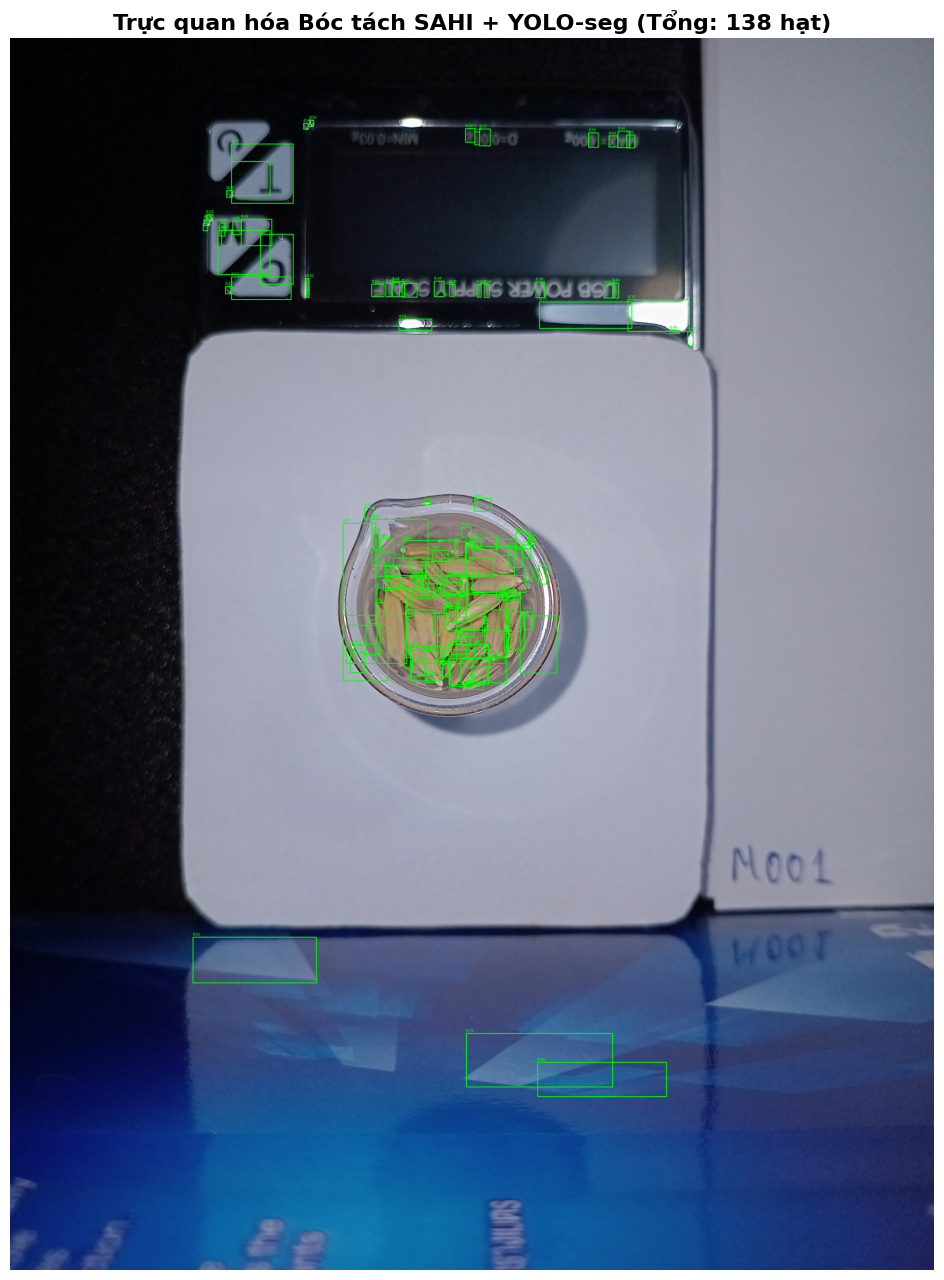

In [5]:
# Bước 5: Trực quan hóa Bounding Box Toàn Bộ Ảnh Gốc
vis_img = cv2.cvtColor(img_bgr.copy(), cv2.COLOR_BGR2RGB)

for g in extracted_grains:
    x1, y1, x2, y2 = g["bbox"]
    score = g["score"]

    # Vẽ viền xanh lá quanh từng hạt
    cv2.rectangle(vis_img, (x1, y1), (x2, y2), (0, 255, 0), 2)
    text = f"{score:.2f}"
    cv2.putText(vis_img, text, (x1, max(y1 - 5, 12)), cv2.FONT_HERSHEY_SIMPLEX, 0.45, (0, 255, 0), 1, cv2.LINE_AA)

plt.figure(figsize=(16, 16))
plt.imshow(vis_img)
plt.title(f"Trực quan hóa Bóc tách SAHI + YOLO-seg (Tổng: {len(extracted_grains)} hạt)", fontsize=16, fontweight="bold")
plt.axis("off")
plt.show()


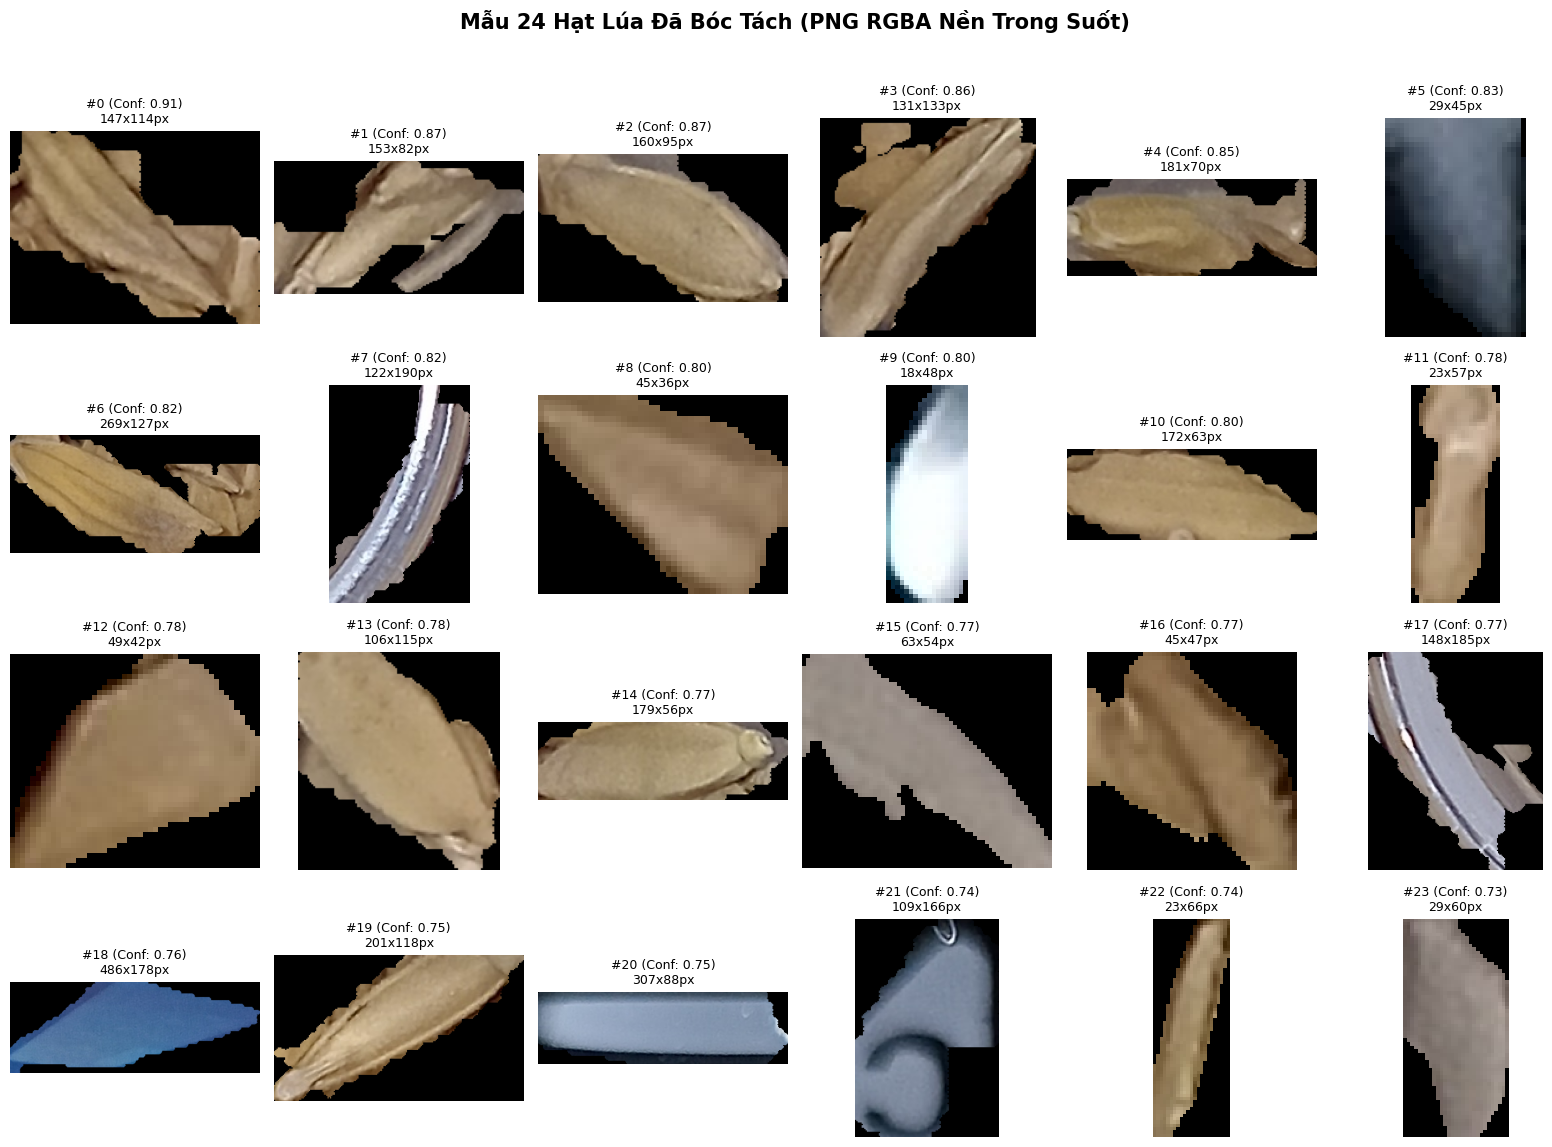

In [6]:
# Bước 6: Hiển thị Thư viện Ảnh Mẫu Hạt Lúa Đã Bóc Tách (Ảnh PNG Nền Trong Suốt)
if extracted_grains:
    num_display = min(24, len(extracted_grains))  # Hiển thị tối đa 24 hạt tiêu biểu
    cols = 6
    rows = math.ceil(num_display / cols)

    plt.figure(figsize=(16, rows * 2.8))
    for i in range(num_display):
        plt.subplot(rows, cols, i + 1)
        g = extracted_grains[i]
        vis_crop = cv2.cvtColor(g["bgr_clean"], cv2.COLOR_BGR2RGB)
        plt.imshow(vis_crop)
        plt.title(f"#{g['index']} (Conf: {g['score']:.2f})\n{g['rgba'].shape[1]}x{g['rgba'].shape[0]}px", fontsize=9)
        plt.axis("off")

    plt.suptitle(f"Mẫu {num_display} Hạt Lúa Đã Bóc Tách (PNG RGBA Nền Trong Suốt)", fontsize=15, fontweight="bold", y=1.02)
    plt.tight_layout()
    plt.show()
else:
    print("❌ Không tìm thấy hạt nào để hiển thị.")


In [7]:
# Bước 7: Nén Toàn Bộ Ảnh Hạt Lúa Thành File .ZIP Để Tải Về Máy
zip_output_path = "/content/segmented_rice_grains"
shutil.make_archive(zip_output_path, 'zip', OUTPUT_PNG_DIR)

print("=" * 60)
print(f"📦 ĐÃ ĐÓNG GÓI THÀNH CÔNG: {zip_output_path}.zip")
print(f"👉 Bạn có thể tải file zip này về máy từ danh sách tệp ở cột bên trái Colab!")
print("=" * 60)


📦 ĐÃ ĐÓNG GÓI THÀNH CÔNG: /content/segmented_rice_grains.zip
👉 Bạn có thể tải file zip này về máy từ danh sách tệp ở cột bên trái Colab!
